# R1：用 NumPy 手写线性回归训练循环

目标：把线性模型、均方误差、梯度与梯度下降逐步写成代码。

本节先完成前向计算和损失函数：

$\hat y=Xw+b$

$L=\frac{1}{n}\sum_{i=1}^{n}(\hat y_i-y_i)^2$

In [1]:
import numpy as np

# 为了让每次运行结果一致
np.set_printoptions(precision=4, suppress=True)

## 1. 构造训练数据

我们使用规律为 \(y=2x+1\) 的四个样本。每一行是一个样本，故 `X` 和 `y` 都是二维列向量。

In [2]:
X = np.array([[1.0], [2.0], [3.0], [4.0]])
y = np.array([[3.0], [5.0], [7.0], [9.0]])

print('X.shape:', X.shape)
print('y.shape:', y.shape)
print('X =\n', X)
print('y =\n', y)

X.shape: (4, 1)
y.shape: (4, 1)
X =
 [[1.]
 [2.]
 [3.]
 [4.]]
y =
 [[3.]
 [5.]
 [7.]
 [9.]]


## 2. 初始化模型参数

模型不知道真实参数，先从 \(w=0,b=0\) 开始。

注意：单特征情况下，`w` 的形状仍写成 `(1, 1)`，以保持和矩阵公式 \(Xw\) 一致。

In [3]:
w = np.zeros((1,1))
b = 0.0

print('w.shape:', w.shape)
print('w =', w)
print('b =', b)

w.shape: (1, 1)
w = [[0.]]
b = 0.0


## 3. 前向计算与均方误差

代码中的 `@` 表示矩阵乘法。初始参数全为 0，所以预测值应全为 0，MSE 损失应为 `41.0`。

In [4]:
# y_hat = Xw + b
y_hat = X @ w + b

# error = y_hat - y
error = y_hat - y

# L = mean(error^2)
loss = np.mean(error ** 2)

print('y_hat =\n', y_hat)
print('error =\n', error)
print('loss =', loss)



y_hat =
 [[0.]
 [0.]
 [0.]
 [0.]]
error =
 [[-3.]
 [-5.]
 [-7.]
 [-9.]]
loss = 41.0


## 4. 调试练习

1. 将 `w` 改成 `[[2.0]]`、`b` 改成 `1.0`，重新运行第 3 节。观察 `y_hat` 与 `loss`。
2. 故意把 `X @ w` 改为 `X * w`，本例中为什么结果暂时没有变化？如果 `X` 有两个特征时，为什么不能继续这样写？
3. 下一节将在下方实现梯度：

$\frac{\partial L}{\partial w}=\frac{2}{n}X^T(\hat y-y)$

$\frac{\partial L}{\partial b}=\frac{2}{n}\sum_{i=1}^{n}(\hat y_i-y_i)$

In [5]:
# TODO：下一节在这里实现梯度，并用 w = w - lr * dw 更新参数。
# 先保留这个单元，不需要现在填写。
pass

In [6]:
n = X.shape[0]
lr = 0.01

dw = 2/n*X.T@(error)
db = 2/n*np.sum(error)

w = w - lr*dw
b = b - lr*db

## 5. 验证一次梯度更新是否有效

更新参数后重新进行前向计算。若梯度和更新方向正确，新的损失应小于初始损失 `41.0`。

In [7]:
# 使用更新后的 w、b 重新计算预测值和损失
y_hat_after_update = X @ w + b
error_after_update = y_hat_after_update - y
loss_after_update = np.mean(error_after_update ** 2)

print('w after update =', w)
print('b after update =', b)
print('loss after update =', loss_after_update)

assert loss_after_update < loss, '损失没有下降，请检查梯度或更新方向。'

w after update = [[0.35]]
b after update = 0.12
loss after update = 28.45315


## 6. 练习：训练循环（training loop）

每个 epoch 都执行：前向计算 → 损失 → 梯度 → 参数更新 → 记录损失。请填完所有 TODO。预期最后 `w` 接近 `2`、`b` 接近 `1`、损失接近 `0`。

In [8]:
# 每次训练都从初始参数开始
w = np.zeros((1, 1))
b = 0.0

lr = 0.01
epochs = 1000
n = X.shape[0]
loss_history = []

for epoch in range(epochs):
    # TODO 1：计算 y_hat
    y_hat = X@w + b
    # TODO 2：计算 error 和 loss
    error = y_hat - y
    loss = np.mean(error**2)
    # TODO 3：计算 dw 和 db
    dw = (2/n) * X.T @ error
    db = (2/n) * np.sum(error)
    # TODO 4：更新 w 和 b
    w = w - lr*dw
    b = b - lr*db
    # TODO 5：记录本轮损失
    loss_history.append(loss)
    if epoch % 100 == 0:
        print(f'epoch={epoch}, loss={loss:.6f}')

print('final w =', w)
print('final b =', b)

epoch=0, loss=41.000000
epoch=100, loss=0.007531
epoch=200, loss=0.004135
epoch=300, loss=0.002270
epoch=400, loss=0.001246
epoch=500, loss=0.000684
epoch=600, loss=0.000376
epoch=700, loss=0.000206
epoch=800, loss=0.000113
epoch=900, loss=0.000062
final w = [[2.0049]]
final b = 0.9857080211211781


## 7. 可视化损失曲线（loss curve）

横轴是训练轮数（epoch），纵轴是均方误差（MSE loss）。曲线持续下降说明梯度下降正在让模型逐步收敛（converge）。

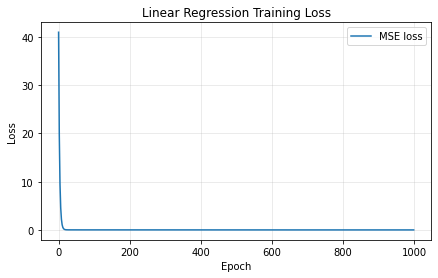

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(loss_history, label='MSE loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Linear Regression Training Loss')
plt.grid(alpha=0.3)
plt.legend()
plt.show()